In [3]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

url = "https://raw.githubusercontent.com/leonism/sample-superstore/master/data/superstore.csv"
df = pd.read_csv(url)

print("Форма:", df.shape)
print(df.head(3))

Форма: (10800, 21)
  Row ID        Order ID Order Date   Ship Date     Ship Mode Customer ID  \
0      1  CA-2017-152156  11/8/2017  11/11/2017  Second Class    CG-12520   
1      2  CA-2017-152156  11/8/2017  11/11/2017  Second Class    CG-12520   
2      3  CA-2017-138688  6/12/2017   6/16/2017  Second Class    DV-13045   

     Customer Name    Segment        Country         City  ... Postal Code  \
0      Claire Gute   Consumer  United States    Henderson  ...     42420.0   
1      Claire Gute   Consumer  United States    Henderson  ...     42420.0   
2  Darrin Van Huff  Corporate  United States  Los Angeles  ...     90036.0   

   Region       Product ID         Category Sub-Category  \
0   South  FUR-BO-10001798        Furniture    Bookcases   
1   South  FUR-CH-10000454        Furniture       Chairs   
2    West  OFF-LA-10000240  Office Supplies       Labels   

                                        Product Name   Sales  Quantity  \
0                  Bush Somerset Collection 


Sales по Category (% от общего):
Category
Furniture          32.3
Office Supplies    31.3
Technology         36.4
Name: Sales, dtype: float64


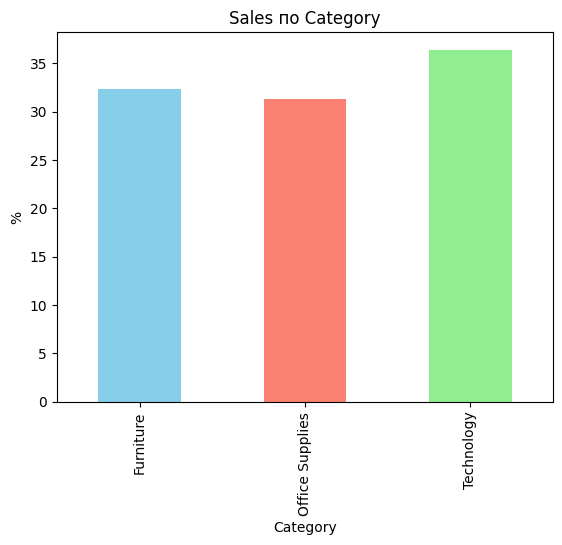

In [22]:
category_sales = df.groupby('Category')['Sales'].sum()
category_pct = (category_sales / category_sales.sum() * 100).round(1)
print("\nSales по Category (% от общего):")
print(category_pct)
category_sales = df.groupby('Category')['Sales'].sum()
category_pct = (category_sales / category_sales.sum() * 100).round(1).plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Sales по Category')
plt.ylabel('%')
plt.show()

In [41]:
top3_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(3)
print(top3_states)

State
California    457687.6315
New York      310876.2710
Texas         170188.0458
Name: Sales, dtype: float64


In [43]:
print(" SUPERSTORE ключевые моменты:")
print(f"• Всего продаж: ${df['Sales'].sum():,.0f}")
print(f"• Топ категория: {df.groupby('Category')['Sales'].sum().idxmax()}")
print("• Топ-3 штата:", top3_states.index.tolist())
print(f"• Выручка маржи: {df['Profit'].sum()/df['Sales'].sum()*100:.1f}%")


 SUPERSTORE ключевые моменты:
• Всего продаж: $2,297,201
• Топ категория: Technology
• Топ-3 штата: ['California', 'New York', 'Texas']
• Выручка маржи: 12.5%
